In [ ]:
!git clone https://github.com/RasheedOlaleye/Linear-Regression.git

Cloning into 'Linear-Regression'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
cd {repo}

/content/Linear-Regression


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded ✓  (numpy, pandas, matplotlib, seaborn — nothing else)')

Libraries loaded ✓  (numpy, pandas, matplotlib, seaborn — nothing else)


In [ ]:

# Download latest version
path = kagglehub.dataset_download("alyelbadry/house-pricing-dataset")

print("Path to dataset files:", path)

100%|██████████| 796k/796k [00:00<00:00, 32.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alyelbadry/house-pricing-dataset/versions/1


In [ ]:
import os
# (Replace 'House_Pricing.csv' with the actual filename printed above if it's different)
files = os.listdir(path)
csv_file_name = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(file_path)
print(f"\nSuccessfully loaded dataframe with {df.shape[0]} rows and {df.shape[1]} columns.")


Successfully loaded dataframe with 21613 rows and 21 columns.


In [ ]:
# Look at the first 5 rows to understand the features
df.head()

# Check data types and look for missing (null) values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  object 
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  object 
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# 1. Get a summary of rows, columns, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  object 
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  object 
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
# 2. Get statistical summaries (mean, min, max, etc.) for numerical columns
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.234303,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.766318,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,4.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


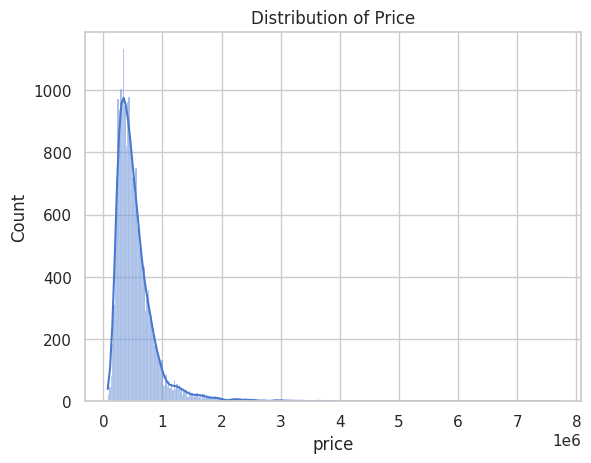

In [ ]:
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.show()

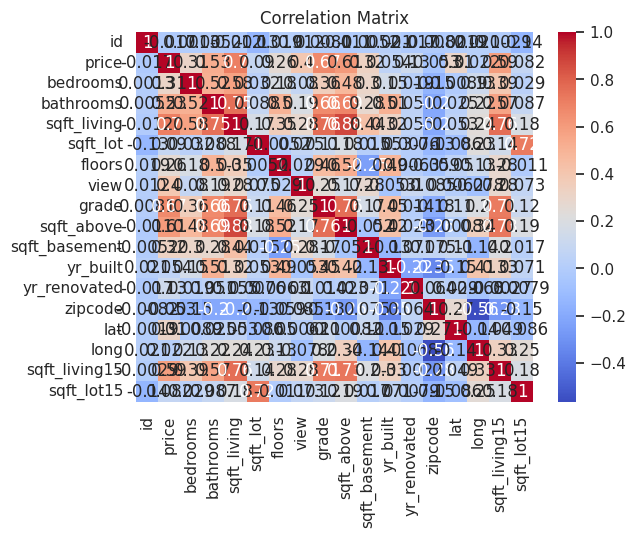

In [ ]:
# Check correlations between numerical variables
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

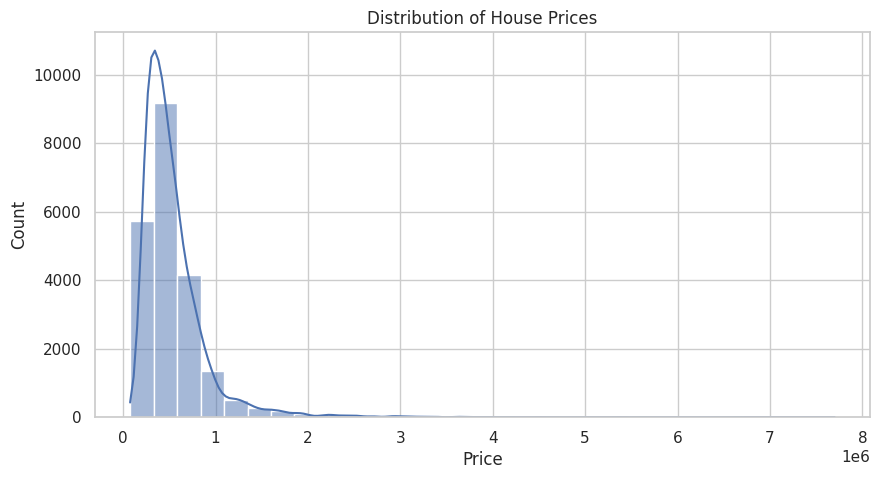

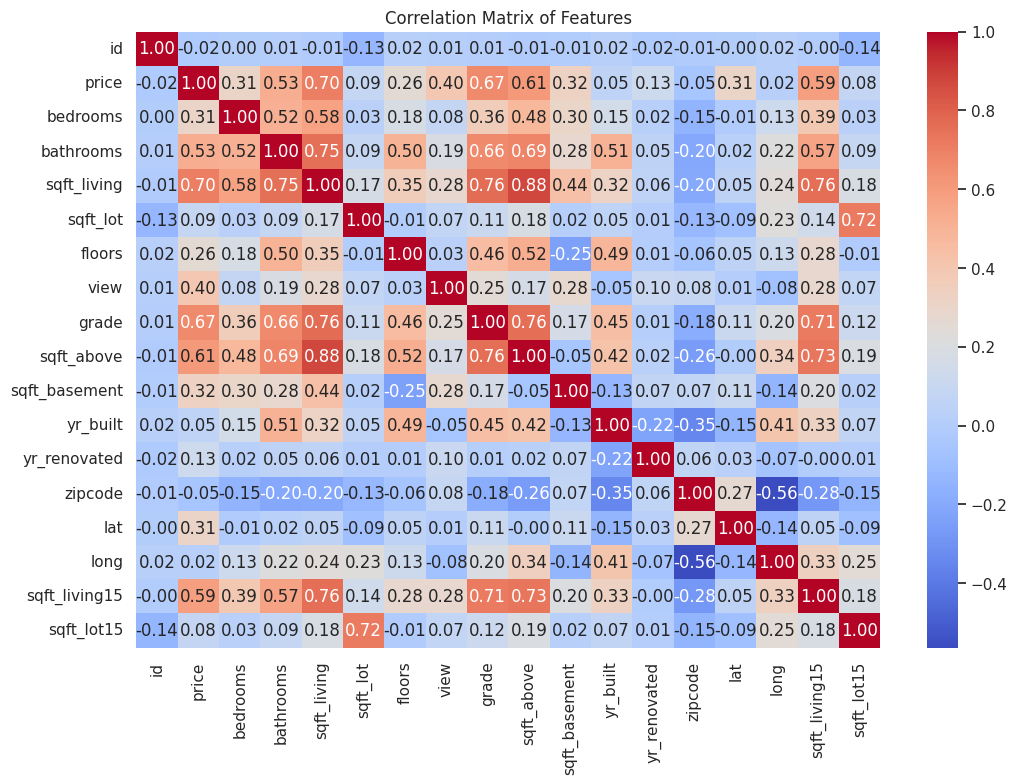

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Distribution of House Prices
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, bins=30) # Using 'price' column directly
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

<Axes: >

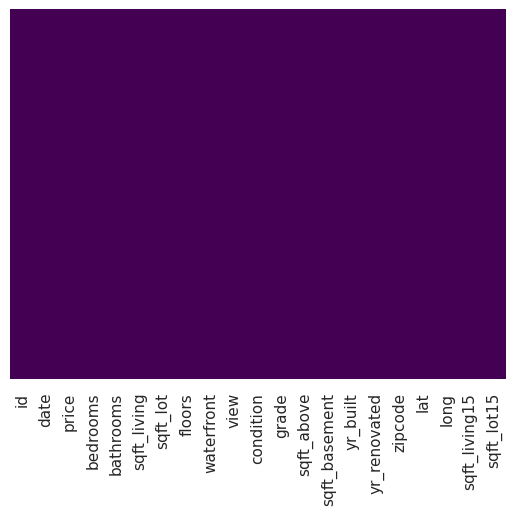

In [ ]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

Text(0.5, 1.0, 'Looking for Outliers in Price')

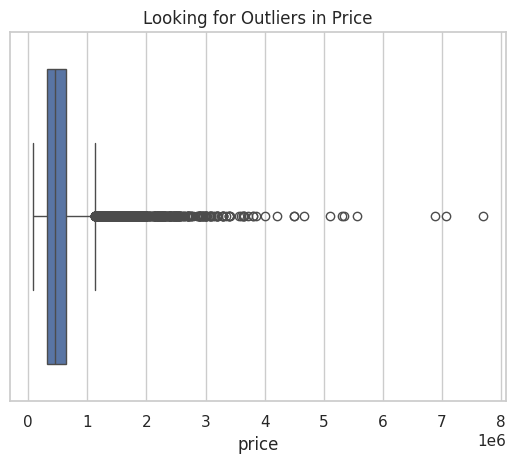

In [ ]:
# Use a Box Plot to look for outliers in the Price column
sns.boxplot(x=df['price']) # Replace 'Price' with your exact column name
plt.title('Looking for Outliers in Price')

,price
zipcode,
98039,2.160607e+06
98004,1.355927e+06
98040,1.194230e+06
98112,1.095499e+06
98102,9.012583e+05
...,...
98148,2.849086e+05
98001,2.808047e+05
98032,2.512962e+05


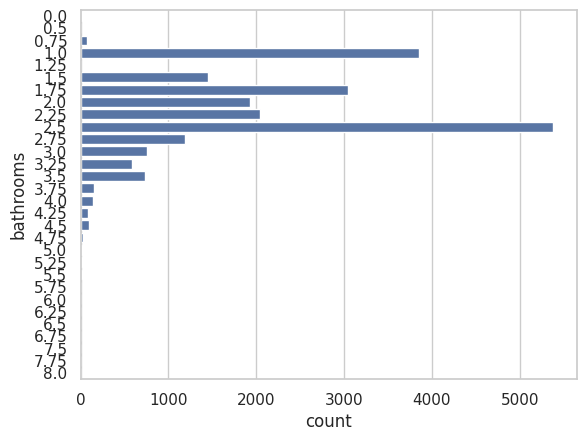

In [ ]:
# Count how many houses are in each neighborhood
sns.countplot(data=df, y='bathrooms')

# Average price per neighborhood (using 'zipcode' as a proxy for neighborhood)
df.groupby('zipcode')['price'].mean().sort_values(ascending=False)

In [ ]:
# Convert text categories into numerical columns (0s and 1s)
df = pd.get_dummies(df, columns=['waterfront'], drop_first=True)

# **Data Preprocessing & Feature Engineering**

In [ ]:
import numpy as np

def standard_scaler(X_train, X_test=None):
    """
    Standardize features by removing the mean and scaling to unit variance.
    Fit on training data, transform both train and test.

    Parameters:
        X_train: np.ndarray — training data
        X_test:  np.ndarray — test data (optional)

    Returns:
        X_train_scaled, X_test_scaled (or just X_train_scaled if no test data)
        mean, std — to reuse or inverse transform later
    """
    mean = np.mean(X_train, axis=0)
    std  = np.std(X_train, axis=0)

    # Avoid division by zero for constant features
    std = np.where(std == 0, 1, std)

    X_train_scaled = (X_train - mean) / std

    if X_test is not None:
        X_test_scaled = (X_test - mean) / std
        return X_train_scaled, X_test_scaled, mean, std

    return X_train_scaled, mean, std


def inverse_transform(X_scaled, mean, std):
    """Reverse the scaling back to original values."""
    return (X_scaled * std) + mean

# **Fix Skewness:**

In [ ]:
import numpy as np
y = np.log1p(df['price']) # Target variable
X = df.drop(columns=['price']) # Predictor variables

# Train-Test **Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Drop the 'date' column as it's a string and not directly useful for linear regression in this format
X_train_processed = X_train.drop(columns=['date'])
X_test_processed = X_test.drop(columns=['date'])

# Handle the 'condition' column by one-hot encoding it
# Ensure to apply get_dummies consistently for train and test
X_train_processed = pd.get_dummies(X_train_processed, columns=['condition'], drop_first=True)
X_test_processed = pd.get_dummies(X_test_processed, columns=['condition'], drop_first=True)

# Initialize the model
model = LinearRegression()

# Train the model on the processed training data
model.fit(X_train_processed, y_train)

LinearRegression()

# **Evaluate the Model**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
predictions = model.predict(X_test_processed)

# Calculate metrics
print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.19634219618895857
RMSE: 0.25536805534213775
R2 Score: 0.7712077173739215


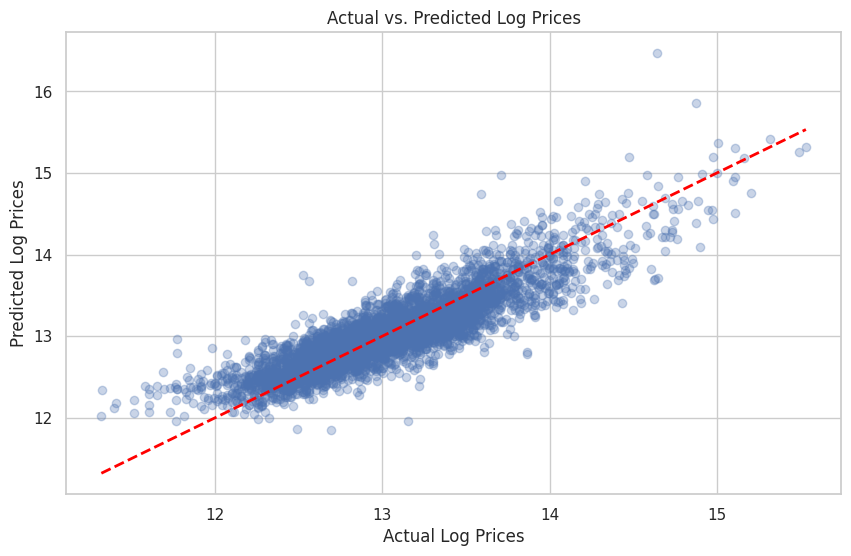

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel("Actual Log Prices")
plt.ylabel("Predicted Log Prices")
plt.title("Actual vs. Predicted Log Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.show()